# Libs

In [ ]:
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os

save_dir = "/home/gorka/overleaf/collective_rl_opts/figures/"

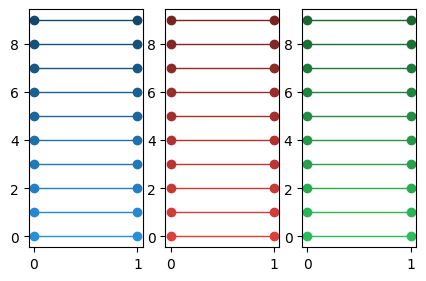

In [ ]:
colors = ['#2790DB', '#DB403D', '#2DBD59', '#a3a3a3', '#FFFFFF', '#000000']
from matplotlib.colors import LinearSegmentedColormap

cmap_blue_full = LinearSegmentedColormap.from_list('custom_cmap', [colors[0], colors[-1]], N=250)  # N is the number of discrete colors
cmap_red_full = LinearSegmentedColormap.from_list('custom_cmap', [colors[1], colors[-1]], N=250)  # N is the number of discrete colors
cmap_green_full = LinearSegmentedColormap.from_list('custom_cmap', [colors[2], colors[-1]], N=250)  # N is the number of discrete colors
cmap_blue_red = LinearSegmentedColormap.from_list('custom_cmap', [colors[0], colors[1]], N=250)  # N is the number of discrete colors


cmap_blue = LinearSegmentedColormap.from_list(
    "cmap_red_trunc",
    cmap_blue_full(np.linspace(0.0, 0.5, 256))
)

cmap_red = LinearSegmentedColormap.from_list(
    "cmap_red_trunc",
    cmap_red_full(np.linspace(0.0, 0.45, 256))
)

cmap_green = LinearSegmentedColormap.from_list(
    "cmap_green_trunc",
    cmap_green_full(np.linspace(0.0, 0.45, 256))
)

# Example
colors_from_cmap = cmap_blue(np.linspace(0, 0.4, 10))

golden_ratio = (1 + 5 ** 0.5) / 2  # Approximately 1.618
width = 5
height = width / golden_ratio

fig, axs = plt.subplots(1, 3, figsize=(width, height))

for cmap, ax in zip([cmap_blue, cmap_red, cmap_green], axs):
    colors_from_cmap = cmap(np.linspace(0, 1, 10))

    for i, color in enumerate(colors_from_cmap):
        ax.plot([0, 1], [i, i], 'o-',color=color, linewidth=1)


# Single agent policy

In [ ]:
out_dir_single = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_8"
taus = [2, 9] #np.arange(2,10)
episodes = 10000

[Text(0, 0.5, 'P(continue)'), 0.0, 1.1]

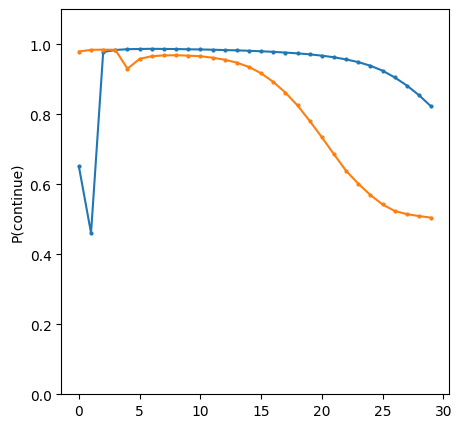

In [ ]:
fig_h, ax = plt.subplots(figsize=(5, 5))


for idx_vr, tau in enumerate(taus):

        file_name = f"_tau_{tau}_ep_{episodes}.npy"
        h_matrix_path = os.path.join(out_dir_single, 
                                     f"h_matrix"+file_name)
        mats = np.load(h_matrix_path)
        hflat = mats.reshape(-1, 2, mats.shape[-1])
        p_keep = hflat[:, 0, :] / hflat.sum(1)
        p_keep = p_keep[:,:30]

        ax.plot(np.mean(p_keep, axis=0), '-o', ms=2, c=f'C{idx_vr}') 

        # Fill between with std
        # p_keep_std = np.std(p_keep, axis=0)
        # ax.fill_between(np.arange(p_keep.shape[-1]), 
        #                 np.mean(p_keep, axis=0) - p_keep_std,
        #                 np.mean(p_keep, axis=0) + p_keep_std,
        #                         color=f'C{idx_vr}', alpha=0.2)
        # ax.text(0.8, 0.1, fr'$\tau$ = '+str(tau), 
        #         transform=ax.transAxes, 
        #         ha='center', va='center', color=f'C{idx_vr}')

plt.setp(ax, ylabel = "P(continue)", ylim = (0, 1.1))


# Collective

In [ ]:
episodes = 10000
time_ep = 5000

num_agents = 50
tau = 2

taus_reward = np.arange(1, 6)#[1, 5]
visual_ranges = np.arange(2, 12) 

shared_depletion = False
out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_3/"

max_counter = 50
if 'agents' not in locals():
    from rl_opts.rl_framework.numba.agents import Foragers_efficient 
    agents = Foragers_efficient(num_agents, 2, np.array([max_counter, 2, 2]))

## Rewards

In [ ]:
rews_mean = np.zeros((len(taus_reward), len(visual_ranges)))
rews_sem = np.zeros((len(taus_reward), len(visual_ranges)))

for idx_t, tau_reward in enumerate(taus_reward):
    for idx_vr, visual_range in enumerate(visual_ranges):
            
        file_name = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes}.npy"
        
        rewards_path = os.path.join(out_dir, 
                                    "rewards"+file_name)
        try:
            rews_run = np.load(rewards_path)/time_ep
        except:
            print(f"File not found: {rewards_path}")
            continue

        if len(rews_run.shape) > 3:
            rews_run = rews_run[:, idx_vr]

        rews_mean[idx_t, idx_vr] = rews_run[:, : , -500:].mean()

        rews_sem[idx_t, idx_vr] = rews_run[:, : , -500:].std() / np.sqrt(np.prod(rews_run.shape[:-1]))

# Baselin Single
rew_single_path = os.path.join(out_dir_single, f"rewards_tau_{tau}_ep_{episodes}.npy")   
rews_single = (np.load(rew_single_path)[:, : , -500:]/time_ep).mean()

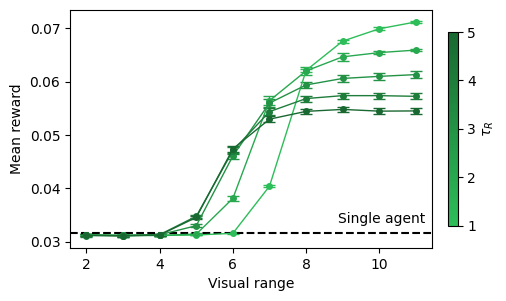

In [ ]:
fig, axs = plt.subplots(figsize=(width, height))

colors_from_cmap = cmap_green(np.linspace(0, 1, len(taus_reward)))
for idx_t, tau_reward in enumerate(taus_reward):
    axs.errorbar(visual_ranges, rews_mean[idx_t, :], yerr=rews_sem[idx_t, :], fmt='-o', ms=4, capsize=4, lw = 1, c = colors_from_cmap[idx_t])

# Baseline
plt.axhline(rews_single, color='k', linestyle='--', label = 'Single agent')
axs.text(0.98, 0.12, fr'Single agent', transform=axs.transAxes, ha='right', va='center', color='k')

plt.setp(axs, xlabel = "Visual range", ylabel = "Mean reward")

# Restrict cmap_red to the same segment used for the plotted lines

sm = plt.cm.ScalarMappable(cmap=cmap_green, norm=plt.Normalize(vmin=taus_reward[0], vmax=taus_reward[-1]))
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.025, pad=0.04)
cbar.set_label(r"$\tau_R$")
cbar.set_ticks(np.linspace(taus_reward[0], taus_reward[-1], num=len(taus_reward)))
cbar.set_ticklabels([str(t) for t in taus_reward])


fig.savefig(save_dir + "rewards.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)

## H-matrices

In [ ]:
tau_reward

np.int64(5)

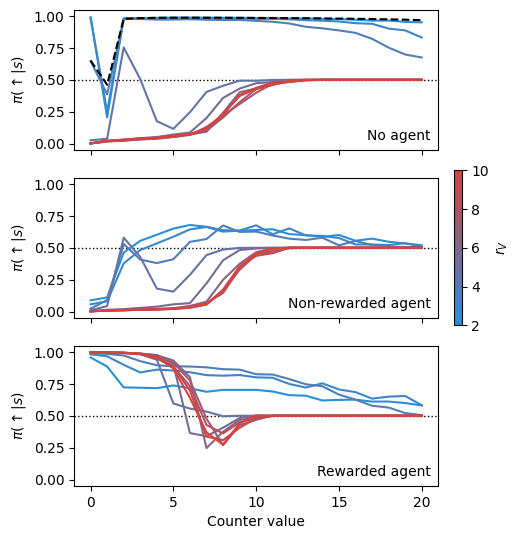

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(1*width, 2*height), sharex=True, sharey = True)


# get colors from cmap
colors_from_cmap = cmap_blue_red(np.linspace(0, 1, len(visual_ranges)))


for idx_vr, visual_range in enumerate(visual_ranges):
    
        file_name = f"_shared_{shared_depletion}_numag_{num_agents}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes}.npy"
                
        h_matrix_path = os.path.join(out_dir, 
                                    f"h_matrix"+file_name)
        
        mats = np.load(h_matrix_path)
        if len(mats.shape) > 4:
            mats = mats[:, idx_vr]
        hflat = mats.reshape(-1, 2, mats.shape[-1])
        p_keep = hflat[:, 0, :] / hflat.sum(1)


        for cone_val in [0, 1]:
            for rew_val in [0, 1]:

                if idx_vr == 0:
                    if cone_val == 0 and rew_val == 0:
                        title = "No agent"
                    if cone_val == 1 and rew_val == 0:
                        title = "Non-rewarded agent"
                    if cone_val == 1 and rew_val == 1:
                        title = "Rewarded agent"

                    if cone_val == 0 and rew_val == 1:  
                        pass
                    else:                      
                        axs[cone_val+rew_val].text(0.98, 0.05, title, transform=axs[cone_val+rew_val].transAxes, ha='right', va='bottom', fontsize=10)

                if cone_val == 0 and rew_val == 1:
                    continue  # impossible state: can't see a rewarded agent if no agents are in the cone

                obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
                obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
                idxs = agents.percept_preprocess(obs)

                

                axs[cone_val+rew_val].plot(np.median(p_keep[:, idxs], axis=0)[:21],
                                                color=colors_from_cmap[idx_vr]) 
                
for a in axs:
     a.axhline(0.5, color='k', linestyle=':', lw=1, zorder = -1)
                
            
# Single agent baseline
mats_single= np.load(os.path.join(out_dir_single, f"h_matrix_tau_{tau}_ep_{episodes}.npy"))
hflat = mats_single.reshape(-1, 2, mats_single.shape[-1])
p_keep = hflat[:, 0, :] / hflat.sum(1)
p_keep = p_keep[:,:21]

axs[0].plot(np.mean(p_keep, axis=0),  ls = '--', c='k') 


sm = plt.cm.ScalarMappable(cmap=cmap_blue_red, norm=plt.Normalize(vmin=visual_ranges[0], vmax=visual_ranges[-1]))
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label(r"$r_V$")
cbar.set_ticks(np.linspace(visual_ranges[0], visual_ranges[-1], num=len(visual_ranges[::2])))
cbar.set_ticklabels([str(t) for t in visual_ranges[::2]])

plt.setp(axs, ylabel = r"$\pi(\uparrow | s)$")
axs[-1].set_xlabel("Counter value")
    
fig.savefig(save_dir + "hmats.pdf", pad_inches = 0, bbox_inches = 'tight', transparent=True)

# Appendix: blind search


In [ ]:
from scipy.optimize import curve_fit

def T_blind_eq18(tau, r, T_inf, B, psi=1.0):
    return T_inf * (1 - B * (r / tau) ** psi)

In [ ]:
Ls = np.linspace(50, 100, 6)
Nt, r = 10, 0.5

mftp_Ls = []
sigma_Ls = []
for l in Ls:
    mftp_Ls.append(np.load(f"data_figures_paper/blind_mftp_avg_L{l:.0f}_Nt_{Nt:.0f}_r_{r:.0f}.npy"))
    sigma_Ls.append(np.load(f"data_figures_paper/blind_mftp_sem_L{l:.0f}_Nt_{Nt:.0f}_r_{r:.0f}.npy"))

[None, None, None, None, None, None]

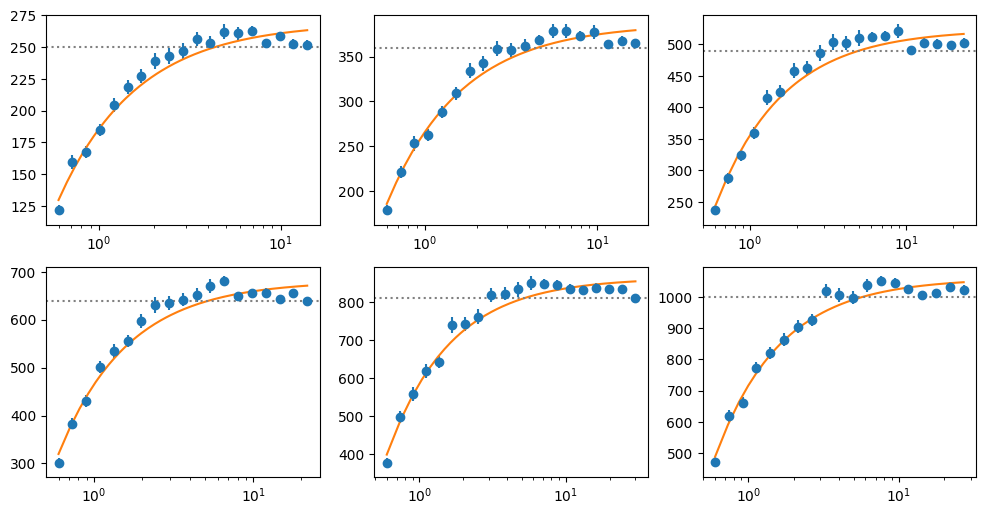

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(3*4, 2*3))

for idxL, (Tb, Sb, L) in enumerate(zip(mftp_Ls, sigma_Ls, Ls)):

    ax = axs.flatten()

    rho = Nt / L**2
    A = 2 / (np.pi * rho)
    B_CELL = 1 / np.sqrt(np.pi * rho)
    MFP = 1 / (2 * r * rho)
    taus_b = np.logspace(np.log10(0.6), np.log10(L/3), 20)
    taus_b = taus_b[taus_b < L / 3]

    f = lambda tau, A, B: A*MFP * (1 - B * (r / tau))

    popt, _ = curve_fit(f, taus_b, Tb, p0=[MFP, 0.4], sigma=Sb, maxfev=20000)
    pred = f(taus_b, *popt)
    R2 = 1 - np.sum((Tb - pred)**2) / np.sum((Tb - Tb.mean())**2)


    [idxL].errorbar(taus_b, Tb, yerr=Sb, fmt='o', label='sim')
    tt = np.linspace(taus_b.min(), taus_b.max(), 200)
    axs.flatten()[idxL].plot(tt, T_blind_eq18(tt, r, T_inf = popt[0]*MFP, B=popt[1]))

    axs.flatten()[idxL].axhline(MFP, color='grey', ls=':', label=f'MFP={MFP:.0f}')

    axs.flatten()[idxL]



plt.setp(axs,  xscale = 'log')

# ; plt.xlabel('tau'); plt.ylabel('T_blind'); plt.legend()
# plt.title('Eq. 18: saturating, not flat'); plt.show()